In [1]:
import mne 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy

In [ ]:
#Load unshuffled acc
import os.path as path
subjects = ['sub05','sub06', 'sub07', 'sub08','sub09','sub10','sub11','sub12','sub13','sub14','sub15','sub16',
'sub18','sub19','sub20','sub21','sub22','sub23', 'sub25', 'sub26', 'sub27', 'sub28', 'sub29', 'sub30', 
'sub31', 'sub32', 'sub33', 'sub34', 'sub35', 'sub36', 'sub37', 'sub38', 'sub39', 'sub40', 'sub41', 'sub42', 'sub43', 
'sub44', 'sub45', 'sub46', 'sub47', 'sub48', 'sub49', 'sub50', 'sub51', 'sub52', 'sub53', 'sub55', 'sub56', 
'sub57', 'sub58', 'sub59', 'sub60', 'sub61', 'sub62',
'sub64', 'sub65', 'sub66', 'sub67', 'sub68', 'sub69', 'sub70', 'sub72']


acctr = []
for subject in subjects:
    print(subject)
    acc_unshuff = pd.read_csv("../trf_results/{s}/fits_acoustic_{s}_within_nb_stan_notr.csv".format(s=subject))
    
    acc_shuff = []
    feats = ['ac_target', 'ac_dis', 'onsets_target', 'onsets_dis']
    #Load shuffled acc
    for feat in feats:
        fn = pd.read_csv("../trf_results/{s}/shuffle/fits_acoustic_{s}_mean599_{f}_within_nb_stan_notr.csv".format(s = subject, i = it, f = feat))
        if path.isfile(fn):
            shuff = pd.read_csv(fn)
            shuff['subject'] = subject
            acc_shuff.append(shuff)

    acc_shuff = pd.concat(acc_shuff)
    
    acc_shuff = acc_shuff.groupby(['trialnum', 'channel','feature_shuffle', 'subject'], as_index = False, sort = False).mean('fit')              
    acc_shuff['feature'] = acc_shuff['feature_shuffle']
    
    #Merge 
    accmere = pd.merge(acc_unshuff, acc_shuff, on = ['subject', 'trialnum', 'channel'])
    accmere['correlation'] = accmere['fit_x'] - accmere['fit_y'] 

    acctr.append(accmere)

sub05
sub06
sub07
sub08
sub09
sub10
sub11
sub12
sub13
sub14
sub15
sub16
sub18
sub19
sub20
sub21
sub22
sub23
sub25
sub26
sub27
sub28
sub29
sub30
sub31
sub32
sub33
sub34
sub35
sub36
sub37
sub38
sub39
sub40
sub41
sub42
sub43
sub44
sub45
sub46
sub47
sub48
sub49
sub50
sub51
sub52
sub53
sub55
sub56
sub57
sub58
sub59
sub60
sub61
sub62
sub64
sub65
sub66
sub67
sub68
sub69
sub70
sub72


In [4]:
acctr = pd.concat(acctr)
dfl=acctr.copy()
dfl = dfl.groupby(['subject', 'channel', 'feature_shuffle'], as_index = False, sort = False).mean('correlation')

In [5]:
dfl['feat'] = dfl['feature_shuffle']

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 61
Clustering.
stat_fun(H1): min=5.94600965602887 max=11.624092187487399
Running initial clustering …
Using 59 thresholds from 0.00 to 11.60 for TFCE computation (h_power=2.00, e_power=0.50)
Found 61 clusters


  0%|          | Permuting : 0/1023 [00:00<?,       ?it/s]

(array([[15.33776398, 14.80235739, 13.53389122, 15.21776398, 15.01776398,
        15.41776398, 15.01776398, 15.45776398, 15.21776398, 15.21776398,
        14.80235739, 15.01776398, 14.57964682, 15.01776398, 14.3298469 ,
        14.57964682, 13.53389122, 14.57964682, 15.33776398, 14.57964682,
        15.3072067 , 15.45776398, 15.4272067 , 14.3298469 , 15.21776398,
        14.3298469 , 15.36377525, 15.41776398, 15.21776398, 15.33776398,
        15.3072067 , 15.21776398, 15.52377525, 15.21776398, 14.57964682,
        15.21776398, 15.39433253, 15.21776398, 15.47433253, 14.57964682,
        11.5151287 ,  9.67956696, 11.21579611, 14.3298469 , 13.53389122,
        14.06754936, 13.25389122, 13.25389122, 11.81177664, 13.80221937,
        11.21579611, 12.3969198 , 11.21579611, 12.3969198 ,  9.05988962,
        12.10571541, 13.53389122, 14.57964682, 15.54746961, 14.57964682,
        15.38746961]]), [(array([0]), array([0])), (array([0]), array([1])), (array([0]), array([2])), (array([0]), array([

  0%|          | Permuting : 0/1023 [00:00<?,       ?it/s]

(array([[15.80454755, 15.80454755, 13.83181855, 12.57407088, 15.40058677,
        16.4297976 , 16.41907963, 16.6297976 , 16.41907963, 16.28051557,
        16.14785058, 16.4297976 , 16.14785058, 16.14785058, 15.98785058,
        14.96977358, 14.30169981, 16.14785058, 16.28051557, 15.98785058,
        15.40058677, 15.98785058, 15.98785058, 15.80454755, 15.80454755,
        13.34850805, 12.83940086, 16.14785058, 16.28051557, 16.36051557,
        16.41907963, 15.60454755, 16.28051557, 15.98785058, 12.30277768,
        13.34850805, 13.09552583, 12.83940086, 13.59181855, 15.40058677,
         9.67693054, 10.57221979, 10.86615856, 14.52797398, 14.75068456,
        14.06846174, 13.34850805, 12.83940086, 12.01993497,  9.37229961,
         9.37229961, 12.30277768, 12.30277768,  9.97892391,  9.97892391,
        12.57407088, 14.30169981, 12.01993497, 12.30277768, 10.86615856,
         9.37229961]]), [(array([0]), array([0])), (array([0]), array([1])), (array([0]), array([2])), (array([0]), array([

  0%|          | Permuting : 0/1023 [00:00<?,       ?it/s]

(array([[ 9.91825202,  9.34377576,  9.91825202,  8.91961989,  9.65292204,
         9.50869999,  8.91961989,  9.50869999,  9.41522188, 10.44078642,
         9.92863056,  9.16941981,  9.3420848 ,  9.34377576,  9.3020848 ,
         9.16941981,  9.16941981,  9.16941981,  8.64249176,  9.91825202,
         9.65292204, 10.12206166,  9.16941981, 10.21150438,  9.61118106,
        10.02408207,  9.3020848 ,  9.16941981,  8.91961989,  9.91825202,
         9.41522188, 10.52078642,  9.7900665 ,  8.64249176, 10.44078642,
         9.98519911,  9.50869999,  8.91961989,  9.16941981,  9.50869999,
         6.8601416 ,  6.55289577,  5.62337977,  8.64249176,  9.16941981,
         8.91961989,  9.16941981,  8.64249176,  8.91961989,  7.76346095,
         8.35404765,  8.91961989,  8.91961989,  7.46412835,  6.8601416 ,
         8.06010888,  8.35404765, 10.37150438, 10.22519911,  8.91961989,
         9.7900665 ]]), [(array([0]), array([0])), (array([0]), array([1])), (array([0]), array([2])), (array([0]), array([

  0%|          | Permuting : 0/1023 [00:00<?,       ?it/s]

(array([[7.47963364, 8.84412113, 7.25692307, 8.10288633, 8.66976517,
        8.29884551, 8.48646214, 8.84412113, 9.3008297 , 7.90288633,
        9.3008297 , 7.02714056, 6.78714056, 7.25692307, 7.02714056,
        6.540564  , 6.78714056, 6.03459958, 8.84412113, 8.99904046,
        9.10487052, 8.99904046, 8.99904046, 9.05560901, 9.59939376,
        7.69504024, 8.66976517, 8.99904046, 9.4608297 , 9.09560901,
        9.92909939, 8.99904046, 9.76909939, 8.99904046, 6.540564  ,
        7.69504024, 7.47963364, 7.90288633, 8.29884551, 8.84412113,
        1.86413161, 3.14666482, 3.06666482, 4.72928317, 5.25691069,
        4.45798997, 4.72928317, 3.34950753, 3.62950753, 1.24963995,
        3.06666482, 2.47339346, 3.06666482, 1.24963995, 2.77272605,
        2.77272605, 4.99461315, 4.18376379, 7.02714056, 2.47339346,
        6.03459958]]), [(array([0]), array([0])), (array([0]), array([1])), (array([0]), array([2])), (array([0]), array([3])), (array([0]), array([4])), (array([0]), array([5])), (ar

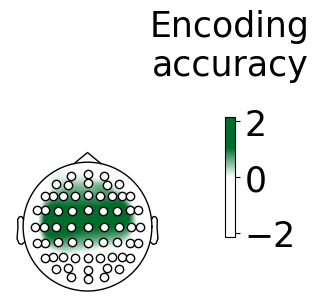

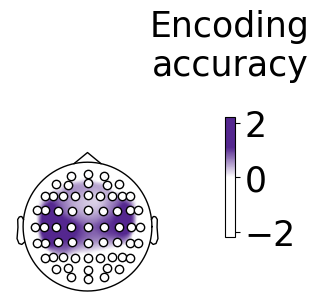

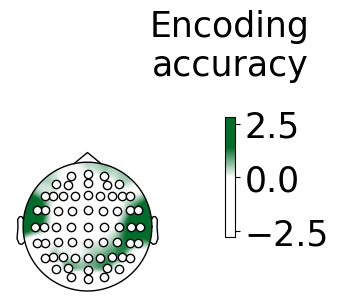

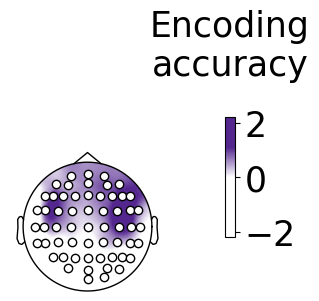

In [ ]:
%run plotting_functions_within.ipynb

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as clr
import copy

cluster_dict = {}

feats = dfl['feat'].unique()

for feat in feats:
    plot_fits_clusters(feat)
    
    sname = "../figures/" + feat  + "_topo_within.svg"
    
    plt.savefig(sname, bbox_inches = "tight")

In [ ]:
sdf = acctr.groupby(['subject', 'feature_shuffle', 'trialnum'], as_index = False, sort = False).mean('correlation')
sdf = sdf[['subject', 'feature_shuffle', 'trialnum', 'correlation']]
sdf.to_csv('../statistics/fits_ac_within.csv')